In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
print("Libraries loaded ✓")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded ✓


In [2]:
df = pd.read_csv("../data/datasets/fraud_dataset.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")


Shape: (40, 19)

Columns:
['contract_verified', 'is_proxy', 'dangerous_function_count', 'top_10_holder_pct', 'largest_wallet_pct', 'suspicious_wallet_count', 'burned_liquidity_pct', 'locked_liquidity_pct', 'creator_lp_pct', 'top_lp_holder_pct', 'creator_controls_liquidity', 'mint_count', 'large_mint_detected', 'ownership_renounced', 'honeypot_signal_count', 'honeypot_risk_encoded', 'address', 'name', 'label']


In [3]:
df.head(10)

,contract_verified,is_proxy,dangerous_function_count,top_10_holder_pct,largest_wallet_pct,suspicious_wallet_count,burned_liquidity_pct,locked_liquidity_pct,creator_lp_pct,top_lp_holder_pct,creator_controls_liquidity,mint_count,large_mint_detected,ownership_renounced,honeypot_signal_count,honeypot_risk_encoded,address,name,label
0,1,0,4,0,0,0,0,0,0,100.38,0,4,1,0,0,0,0x09a3EcAFa817268f77BE1283176B946C4ff2E608,MIR_FAKE,scam
1,1,0,1,0,0,0,0,0,0,345.00,0,2,1,0,0,0,0x0bc529c00C6401aEF6D220BE8C6Ea1667F6Ad93e,YFI,safe
2,1,0,4,0,0,0,0,0,0,1757.56,0,1,1,1,0,0,0x111111111117dC0aa78b770fA6A738034120C302,1INCH,safe
3,1,0,2,0,0,0,0,0,0,5.03,0,1,1,0,0,0,0x1f9840a85d5aF5bf1D1762F925BDADdC4201F984,UNI,safe
4,1,0,4,0,0,0,0,0,0,35.31,0,7,0,0,0,0,0x2260FAC5E5542a773Aa44fBCfeDf7C193bc2C599,WBTC,safe
5,1,0,2,0,0,0,0,0,0,0.00,0,1,1,0,0,0,0x29127fE04ffa4c32AcAC0fFe17280ABD74eAC313,INUBIS,scam
6,0,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0,1,0x34BA3af693d6c776d73C7fa67e2B2e79be8ef4ED,SAFEMOON_ETH,scam
7,1,0,3,0,0,0,0,0,0,1198.37,0,1,1,0,0,0,0x35bD01FC9d6D5D81CA9E055Db88Dc49aa2c699A8,FWB_FAKE,scam
8,1,0,2,0,0,0,0,0,0,214.58,0,1,1,0,0,0,0x3845badAde8e6dFF049820680d1F14bD3903a5d0,SAND_FAKE,scam
9,1,0,2,0,0,0,0,0,0,47875.86,0,1,1,0,0,0,0x491604c0FDF08347Dd1fa4Ee062a822A5DD06B5D,CTSI_FAKE,scam


Label distribution:
label
scam    20
safe    20
Name: count, dtype: int64


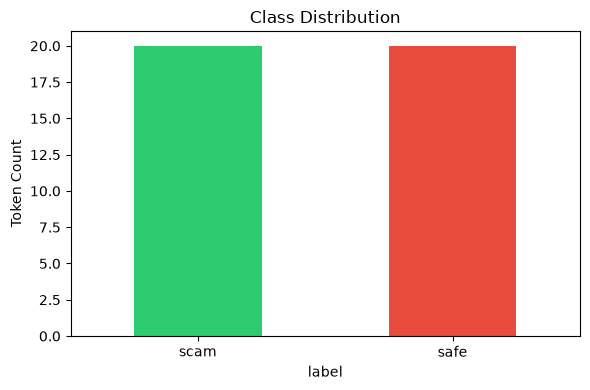

In [4]:
print("Label distribution:")
print(df["label"].value_counts())

df["label"].value_counts().plot(
    kind="bar",
    color=["#2ecc71", "#e74c3c"],
    title="Class Distribution",
    figsize=(6, 4)
)
plt.xticks(rotation=0)
plt.ylabel("Token Count")
plt.tight_layout()
plt.show()

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
contract_verified             0
is_proxy                      0
dangerous_function_count      0
top_10_holder_pct             0
largest_wallet_pct            0
suspicious_wallet_count       0
burned_liquidity_pct          0
locked_liquidity_pct          0
creator_lp_pct                0
top_lp_holder_pct             0
creator_controls_liquidity    0
mint_count                    0
large_mint_detected           0
ownership_renounced           0
honeypot_signal_count         0
honeypot_risk_encoded         0
address                       0
name                          0
label                         0
dtype: int64


In [6]:
# Separate features from metadata columns
feature_cols = [
    "contract_verified", "is_proxy", "dangerous_function_count",
    "top_10_holder_pct", "largest_wallet_pct", "suspicious_wallet_count",
    "burned_liquidity_pct", "locked_liquidity_pct", "creator_lp_pct",
    "top_lp_holder_pct", "creator_controls_liquidity",
    "mint_count", "large_mint_detected", "ownership_renounced",
    "honeypot_signal_count", "honeypot_risk_encoded"
]

print(df[feature_cols].describe().round(2))

       contract_verified  is_proxy  dangerous_function_count  \
count              40.00     40.00                     40.00   
mean                0.92      0.12                      1.95   
std                 0.27      0.33                      1.43   
min                 0.00      0.00                      0.00   
25%                 1.00      0.00                      1.00   
50%                 1.00      0.00                      2.00   
75%                 1.00      0.00                      3.00   
max                 1.00      1.00                      4.00   

       top_10_holder_pct  largest_wallet_pct  suspicious_wallet_count  \
count               40.0                40.0                     40.0   
mean                 0.0                 0.0                      0.0   
std                  0.0                 0.0                      0.0   
min                  0.0                 0.0                      0.0   
25%                  0.0                 0.0              

Feature Variance (low = potentially useless):
top_10_holder_pct             0.000000e+00
burned_liquidity_pct          0.000000e+00
suspicious_wallet_count       0.000000e+00
largest_wallet_pct            0.000000e+00
locked_liquidity_pct          0.000000e+00
creator_lp_pct                0.000000e+00
creator_controls_liquidity    0.000000e+00
ownership_renounced           2.500000e-02
contract_verified             7.120000e-02
honeypot_risk_encoded         9.230000e-02
honeypot_signal_count         1.000000e-01
is_proxy                      1.122000e-01
large_mint_detected           2.506000e-01
dangerous_function_count      2.048700e+00
mint_count                    8.283359e+02
top_lp_holder_pct             2.468665e+09
dtype: float64


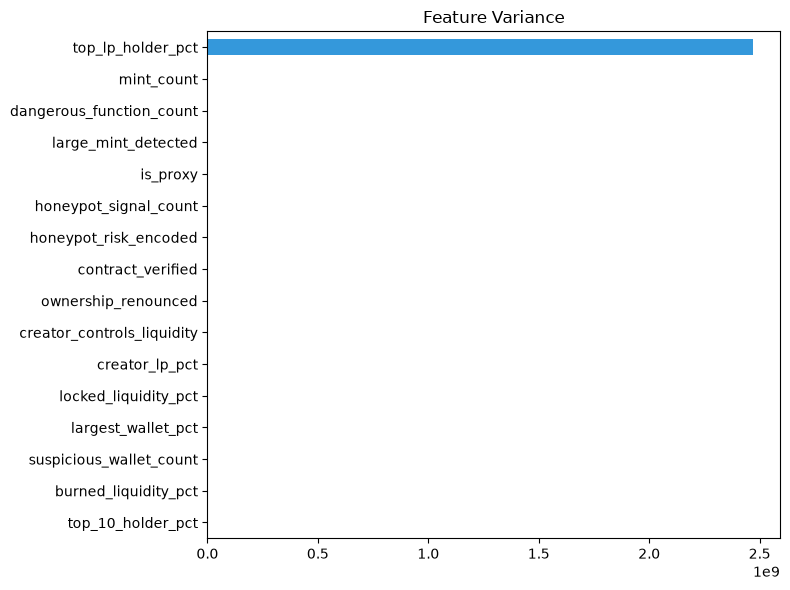

In [7]:
variance = df[feature_cols].var().sort_values()
print("Feature Variance (low = potentially useless):")
print(variance.round(4))

variance.plot(
    kind="barh",
    figsize=(8, 6),
    title="Feature Variance",
    color="#3498db"
)
plt.tight_layout()
plt.show()

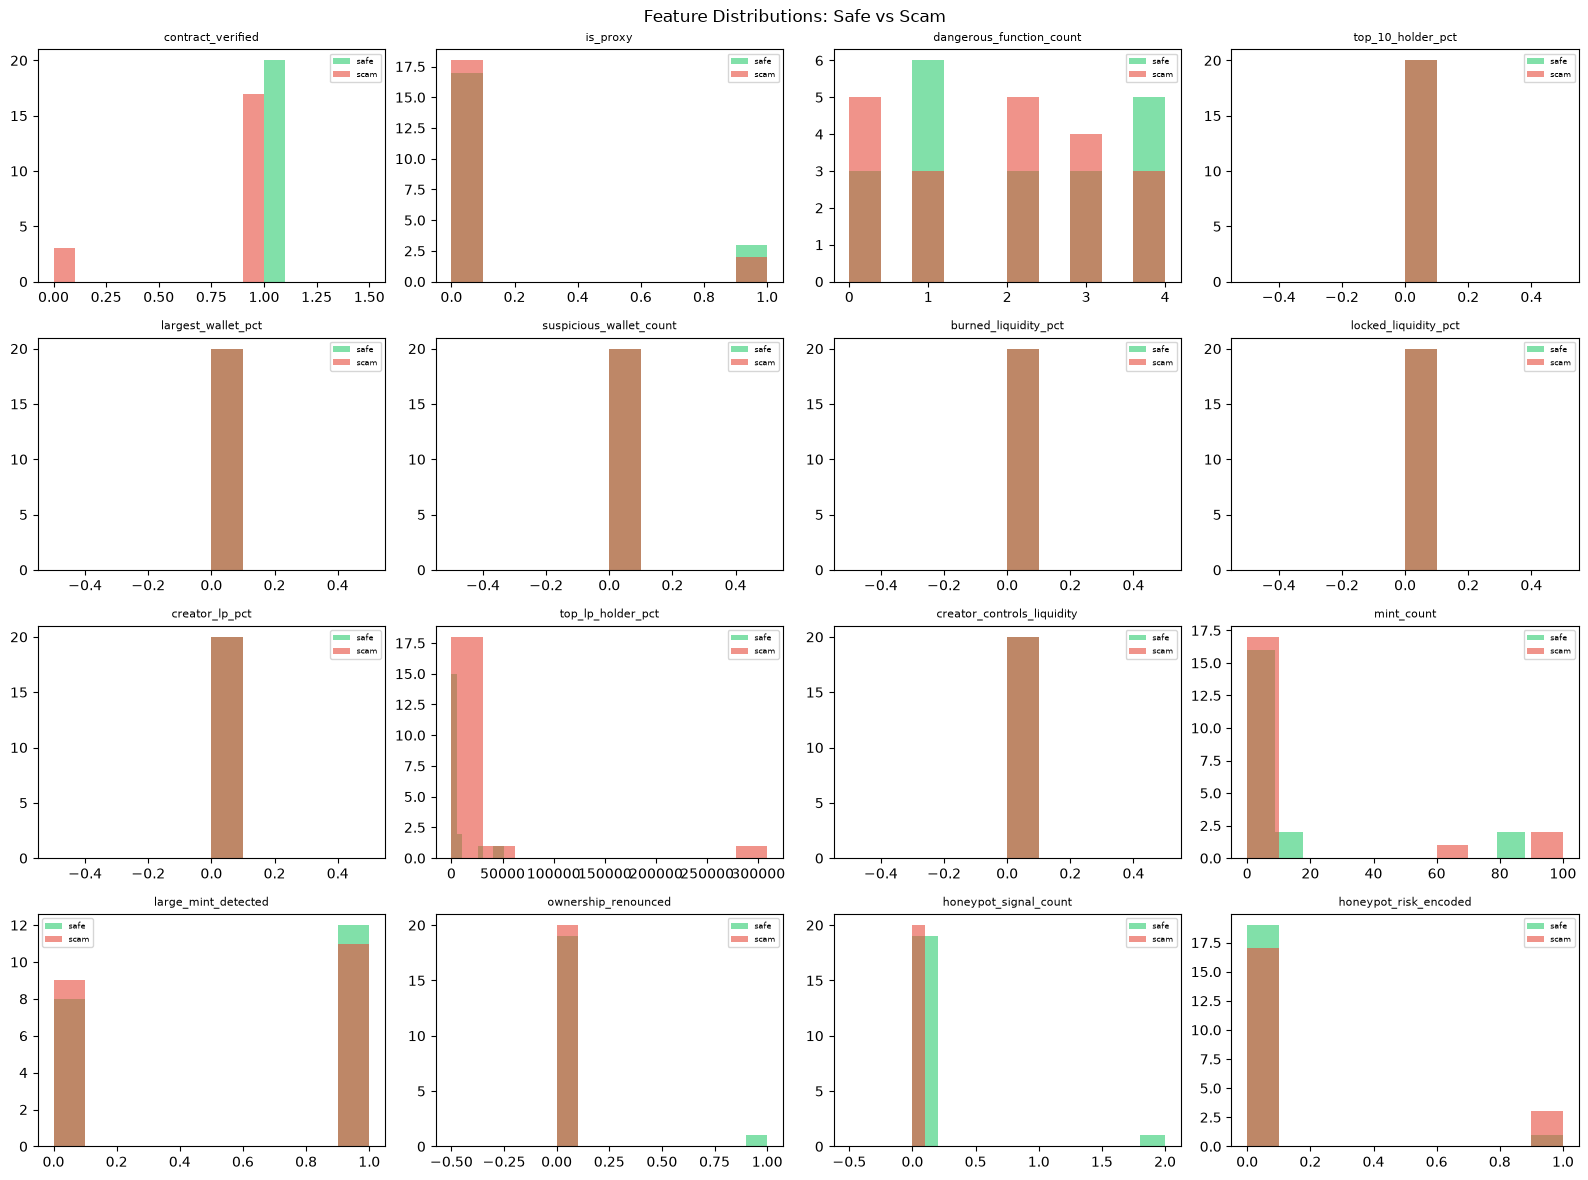

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    safe_vals = df[df["label"] == "safe"][col]
    scam_vals = df[df["label"] == "scam"][col]
    axes[i].hist(safe_vals, bins=10, alpha=0.6, color="#2ecc71", label="safe")
    axes[i].hist(scam_vals, bins=10, alpha=0.6, color="#e74c3c", label="scam")
    axes[i].set_title(col, fontsize=8)
    axes[i].legend(fontsize=6)

plt.suptitle("Feature Distributions: Safe vs Scam", fontsize=12)
plt.tight_layout()
plt.show()

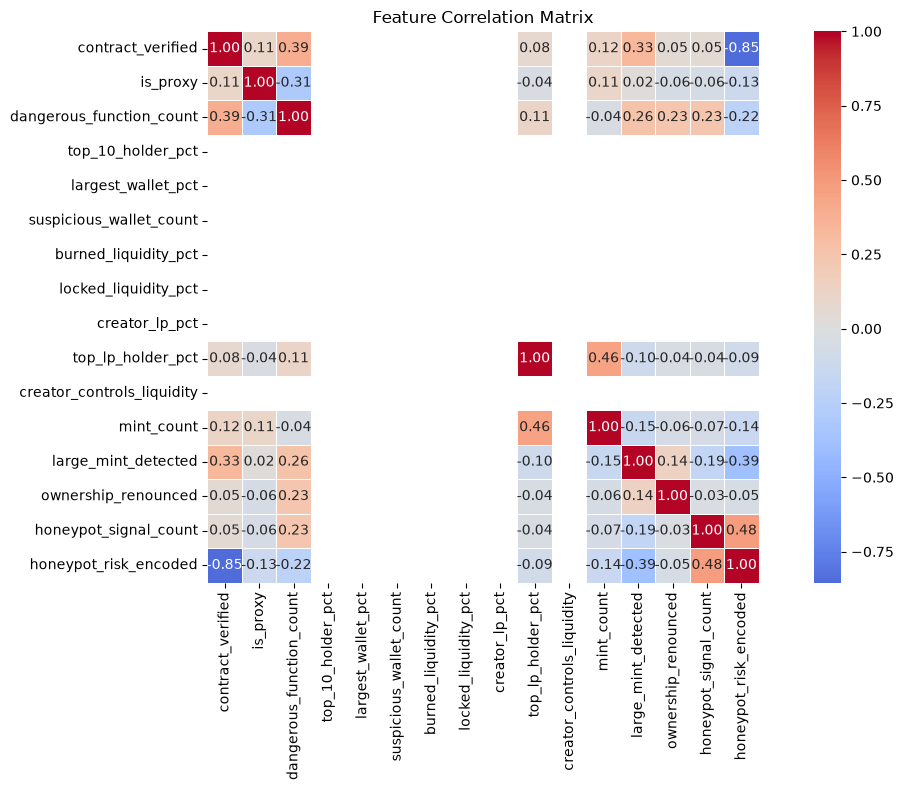

In [9]:
plt.figure(figsize=(12, 8))
corr = df[feature_cols].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

print("Label encoding:")
for label, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {label} → {code}")

print(f"\nFinal dataset shape: {df.shape}")

Label encoding:
  safe → 0
  scam → 1

Final dataset shape: (40, 20)


In [11]:
# Drop zero-variance features
drop_features = [
    "top_10_holder_pct",
    "burned_liquidity_pct",
    "suspicious_wallet_count",
    "largest_wallet_pct",
    "locked_liquidity_pct",
    "creator_lp_pct",
    "creator_controls_liquidity"
]

# Final feature columns
FEATURE_COLS = [
    "contract_verified",
    "is_proxy",
    "dangerous_function_count",
    "ownership_renounced",
    "large_mint_detected",
    "mint_count",
    "top_lp_holder_pct",
    "honeypot_signal_count",
    "honeypot_risk_encoded"
]

X = df[FEATURE_COLS]
y = df["label_encoded"]

print(f"Features shape : {X.shape}")
print(f"Labels shape   : {y.shape}")
print(f"\nFeature columns kept:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i}. {col}")
print(f"\nLabel distribution:")
print(y.value_counts())

Features shape : (40, 9)
Labels shape   : (40,)

Feature columns kept:
  1. contract_verified
  2. is_proxy
  3. dangerous_function_count
  4. ownership_renounced
  5. large_mint_detected
  6. mint_count
  7. top_lp_holder_pct
  8. honeypot_signal_count
  9. honeypot_risk_encoded

Label distribution:
label_encoded
1    20
0    20
Name: count, dtype: int64
